
# 01 — Real-data preparation: CAISO curtailment + Alibaba Spot A100 jobs

This notebook constructs the **fixed empirical workload** and the **20 real renewable-curtailment events** used by the optimization study.

The scientific design is intentionally narrow:

> **Can a queued portfolio of opportunistic A100 GPU jobs shape its electrical demand to follow renewable electricity that CAISO would otherwise curtail?**

No synthetic renewable signal is used. The CAISO workbook supplies five-minute wind/solar curtailment records. The Alibaba `cluster-trace-v2026-spot-gpu` trace supplies real Spot-job GPU counts and runtimes.

### Benchmark design
- CAISO: 20 independent six-hour events, 15-minute slots, at least 24 h between event starts.
- GPU portfolio: one **fixed** portfolio of 48 real Alibaba Spot jobs using `A100-SXM4-80GB`.
- Job sizes: stratified across 8–16, 17–64, and 65–256 GPUs.
- Job duration: 15–180 min, conservatively rounded **up** to the next 15-min slot.
- A100 electrical power: **0.400 kW/GPU**, from NVIDIA's standard 400 W TDP specification for the A100 80GB SXM.
- Flexible-pod envelope: 300 kW peak. A single global scale factor maps the 20 CAISO events into this pod-scale envelope, preserving relative event severity.
- Dispatch target: 80% of the allocated curtailment envelope, deliberately leaving 20% headroom for discrete-job granularity.

The same 48-job portfolio is used for all 20 grid events. Consequently the QUBO's quadratic coupling matrix is static across events; only event-dependent linear biases change.


In [1]:

from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from ai_spot_curtailment_qubo_core import (
    StudyConfig, prepare_all, build_qubo, random_equivalence_tests
)

# Edit only if your files are elsewhere.
CAISO_XLSX = Path("production-and-curtailments-data-2025.xlsx")
ALIBABA_ZIP = Path("clusterdata-master.zip")
OUT = Path("prepared_ai_curtailment")

# Helpful fallbacks when running inside a copied repository.
for candidate in [Path.cwd()/CAISO_XLSX.name, Path('/mnt/data')/CAISO_XLSX.name]:
    if candidate.exists(): CAISO_XLSX = candidate; break
for candidate in [Path.cwd()/ALIBABA_ZIP.name, Path('/mnt/data')/ALIBABA_ZIP.name]:
    if candidate.exists(): ALIBABA_ZIP = candidate; break

CFG = StudyConfig(
    slot_minutes=15,
    event_hours=6,
    n_events=20,
    min_event_separation_hours=24,
    gpu_model="A100-SXM4-80GB",
    gpu_tdp_kw=0.400,
    n_jobs_small=26,
    n_jobs_medium=16,
    n_jobs_large=6,
    seed_jobs=99,
    pod_cap_kw=300.0,
    target_fraction_of_envelope=0.80,
    lambda_once=30.0,
)
print(CFG)
print("CAISO:", CAISO_XLSX.resolve())
print("Alibaba:", ALIBABA_ZIP.resolve())


StudyConfig(slot_minutes=15, event_hours=6, n_events=20, min_event_separation_hours=24, gpu_model='A100-SXM4-80GB', gpu_tdp_kw=0.4, n_jobs_small=26, n_jobs_medium=16, n_jobs_large=6, job_duration_min_minutes=15.0, job_duration_max_minutes=180.0, seed_jobs=99, pod_cap_kw=300.0, target_fraction_of_envelope=0.8, lambda_once=30.0, cplex_time_limit_s=30.0, cplex_mip_gap=0.01, sa_num_reads=500, sa_num_sweeps=5000, sa_seed=20260902)
CAISO: /Users/kumarghosh/Desktop/other_projects_till_Jul_5/Energy_mix/GPU_opt/production-and-curtailments-data-2025.xlsx
Alibaba: /Users/kumarghosh/Desktop/other_projects_till_Jul_5/Energy_mix/GPU_opt/clusterdata-master.zip



## Build the processed dataset

`prepare_all` performs the complete deterministic pipeline:

1. extracts only the Alibaba 2026 Spot-GPU files from the repository ZIP;
2. reconstructs CAISO five-minute timestamps from operating date, hour and interval;
3. aggregates duplicate Local/System curtailment records for the same five-minute interval;
4. resamples to 15-minute mean MW, preserving energy;
5. ranks six-hour windows by curtailed MWh and greedily retains 20 event starts separated by at least 24 h;
6. filters real Alibaba Spot jobs to A100 SXM4 80GB, integer GPU count, 8–256 GPUs, and 15–180 min runtime;
7. selects a fixed 48-job stratified portfolio with seed 99;
8. builds the 20 pod-scale curtailment profiles and a structural QUBO smoke test.


In [2]:

paths = prepare_all(CAISO_XLSX, ALIBABA_ZIP, OUT, CFG)
paths


{'caiso15': PosixPath('prepared_ai_curtailment/caiso_15min.csv'),
 'events': PosixPath('prepared_ai_curtailment/selected_caiso_events.csv'),
 'profiles': PosixPath('prepared_ai_curtailment/event_profiles_long.csv'),
 'portfolio': PosixPath('prepared_ai_curtailment/benchmark_spot_jobs.csv'),
 'vartable': PosixPath('prepared_ai_curtailment/start_variable_table.csv'),
 'equivalence': PosixPath('prepared_ai_curtailment/qubo_equivalence_smoketest.csv'),
 'manifest': PosixPath('prepared_ai_curtailment/data_and_qubo_manifest.json'),
 'alibaba_readme': PosixPath('prepared_ai_curtailment/alibaba_extract/README.md'),
 'alibaba_nodes': PosixPath('prepared_ai_curtailment/alibaba_extract/node_info_df.csv')}

In [3]:

manifest = json.loads(Path(paths["manifest"]).read_text())
print(json.dumps(manifest, indent=2))

events = pd.read_csv(paths["events"], parse_dates=["start","end"])
profiles = pd.read_csv(paths["profiles"], parse_dates=["timestamp"])
portfolio = pd.read_csv(paths["portfolio"])
vartable = pd.read_csv(paths["vartable"])
eq = pd.read_csv(paths["equivalence"])

display(events)
display(portfolio[["portfolio_job_id","job_name","organization","total_gpus","duration_minutes","duration_slots","gpu_power_kW","start_options"]])
print("QUBO variables:", manifest["qubo_variables"])
print("QUBO edges:", f'{manifest["qubo_edges"]:,}')
print("QUBO density:", f'{100*manifest["qubo_density"]:.2f}%')
print("Equivalence max |error|:", eq.abs_error.max())


{
  "config": {
    "slot_minutes": 15,
    "event_hours": 6,
    "n_events": 20,
    "min_event_separation_hours": 24,
    "gpu_model": "A100-SXM4-80GB",
    "gpu_tdp_kw": 0.4,
    "n_jobs_small": 26,
    "n_jobs_medium": 16,
    "n_jobs_large": 6,
    "job_duration_min_minutes": 15.0,
    "job_duration_max_minutes": 180.0,
    "seed_jobs": 99,
    "pod_cap_kw": 300.0,
    "target_fraction_of_envelope": 0.8,
    "lambda_once": 30.0,
    "cplex_time_limit_s": 30.0,
    "cplex_mip_gap": 0.01,
    "sa_num_reads": 500,
    "sa_num_sweeps": 5000,
    "sa_seed": 20260902
  },
  "input_caiso": "/Users/kumarghosh/Desktop/other_projects_till_Jul_5/Energy_mix/GPU_opt/production-and-curtailments-data-2025.xlsx",
  "input_alibaba_zip": "/Users/kumarghosh/Desktop/other_projects_till_Jul_5/Energy_mix/GPU_opt/clusterdata-master.zip",
  "alibaba_spot_jobs_total_raw": 51154,
  "filtered_A100_spot_jobs": 3204,
  "selected_jobs": 48,
  "selected_job_total_gpu_power_kW": 536.0,
  "qubo_variables": 962,
 

,event_id,start,end,raw_curtailment_MWh,mean_curtailment_MW,max_curtailment_MW,min_curtailment_MW,fraction_positive
0,0,2025-05-18 10:30:00,2025-05-18 16:15:00,52412.138312,8735.356385,9703.922607,7603.794454,1.0
1,1,2025-03-18 11:15:00,2025-03-18 17:00:00,52128.136208,8688.022701,10455.091649,6753.784414,1.0
2,2,2025-03-29 10:15:00,2025-03-29 16:00:00,51534.122713,8589.020452,9537.061124,7160.735733,1.0
3,3,2025-04-05 10:15:00,2025-04-05 16:00:00,48967.328236,8161.221373,9132.952944,7022.721348,1.0
4,4,2025-03-15 11:15:00,2025-03-15 17:00:00,48444.136280,8074.022713,9968.503121,6166.478644,1.0
5,5,2025-03-20 11:00:00,2025-03-20 16:45:00,47229.905466,7871.650911,9351.780381,6519.142495,1.0
6,6,2025-03-09 10:45:00,2025-03-09 16:30:00,45646.921754,7607.820292,9018.553282,6298.347145,1.0
7,7,2025-04-20 10:30:00,2025-04-20 16:15:00,44339.966787,7389.994464,9345.964718,5352.268262,1.0
8,8,2025-04-19 10:30:00,2025-04-19 16:15:00,42273.369176,7045.561529,8337.392675,5667.077878,1.0
9,9,2025-04-06 10:15:00,2025-04-06 16:00:00,40604.678070,6767.446345,7164.121782,6055.267734,1.0


,portfolio_job_id,job_name,organization,total_gpus,duration_minutes,duration_slots,gpu_power_kW,start_options
0,0,454629,57,12,87.516667,6,4.8,19
1,1,447084,57,8,20.066667,2,3.2,23
2,2,465239,43,8,16.550000,2,3.2,23
3,3,442473,57,8,92.666667,7,3.2,18
4,4,450855,43,8,152.916667,11,3.2,14
5,5,421441,57,8,76.900000,6,3.2,19
6,6,419814,57,13,40.150000,3,5.2,22
7,7,453374,43,8,74.966667,5,3.2,20
8,8,432546,57,8,37.900000,3,3.2,22
9,9,426052,57,10,84.666667,6,4.0,19


QUBO variables: 962
QUBO edges: 168,823
QUBO density: 36.52%
Equivalence max |error|: 1.2505552149377765e-12



## Inspect the real grid events

The raw CAISO values remain in MW. The optimization does **not** claim that one data-centre pod could absorb gigawatts of system-wide curtailment. Instead, a **single global scaling factor** allocates a small, fixed share of those real profiles to a 300 kW flexible GPU pod. This preserves the temporal shape and relative severity of the selected CAISO events.


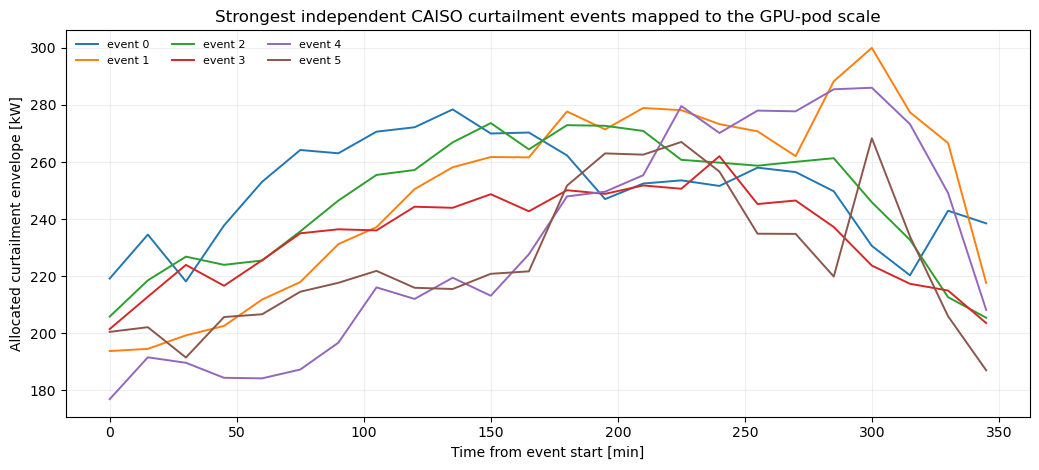

In [4]:

fig, ax = plt.subplots(figsize=(10.5,4.8))
for event_id in range(min(6, CFG.n_events)):
    p = profiles[profiles.event_id==event_id].sort_values("slot")
    ax.plot(p.slot*CFG.slot_minutes, p.allocated_curtailment_kW, lw=1.4, label=f"event {event_id}")
ax.set_xlabel("Time from event start [min]")
ax.set_ylabel("Allocated curtailment envelope [kW]")
ax.set_title("Strongest independent CAISO curtailment events mapped to the GPU-pod scale")
ax.grid(alpha=.2); ax.legend(ncol=3, fontsize=8, frameon=False)
fig.tight_layout()
OUT.mkdir(exist_ok=True)
fig.savefig(OUT/"fig_data_caiso_selected_events.pdf", bbox_inches="tight")
plt.show()



## Inspect the empirical Spot-job portfolio

Only named A100 SXM4 80GB jobs are retained. This avoids assigning speculative power ratings to Alibaba's anonymized GPU series. The original trace's `gpu_request × worker_num` gives total GPUs requested by a job. The selected portfolio is intentionally heterogeneous in GPU count and duration because this heterogeneity is what makes curtailment matching combinatorial.


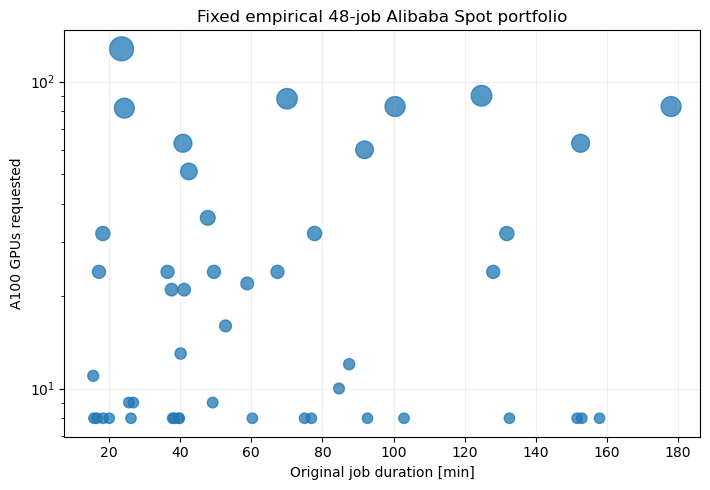

Total simultaneous GPU-board power if every selected job were active: 536.0 kW
Median original duration: 49.3 min
Total feasible binary start choices: 962


In [5]:

fig, ax = plt.subplots(figsize=(7.2,5.0))
sc = ax.scatter(portfolio.duration_minutes, portfolio.total_gpus, s=40 + 2*portfolio.total_gpus, alpha=.75)
ax.set_xlabel("Original job duration [min]")
ax.set_ylabel("A100 GPUs requested")
ax.set_yscale("log")
ax.set_title("Fixed empirical 48-job Alibaba Spot portfolio")
ax.grid(alpha=.2)
fig.tight_layout()
fig.savefig(OUT/"fig_data_alibaba_job_portfolio.pdf", bbox_inches="tight")
plt.show()

print("Total simultaneous GPU-board power if every selected job were active:",
      f"{portfolio.gpu_power_kW.sum():.1f} kW")
print("Median original duration:", f"{portfolio.duration_minutes.median():.1f} min")
print("Total feasible binary start choices:", int(portfolio.start_options.sum()))



## Structural QUBO check

For a start variable \(x_{j,s}\), a job contributes its power to every slot covered by its duration. The objective for event \(e\) is

\[
H_{\rm track}^{(e)}=\sum_{t=1}^{24}
\left[\frac{P_{\rm GPU}(t)-P_{\rm target}^{(e)}(t)}{P_{\rm pod}}\right]^2,
\]

plus a quadratic at-most-once penalty between alternative starts of the **same empirical job**.

Because squaring aggregate power generates pairwise products between overlapping job-start variables, the objective is intrinsically quadratic and fairly dense. The curtailment target only contributes to the linear term, so the quadratic matrix is common to all 20 events.


In [6]:

q0 = build_qubo(portfolio, profiles[profiles.event_id==0], CFG)
print(f"binary variables = {q0['n_variables']}")
print(f"quadratic edges  = {q0['n_edges']:,}")
print(f"edge density     = {100*q0['density']:.2f}%")
assert q0['n_variables'] <= 1000

eq2 = random_equivalence_tests(q0, portfolio, profiles[profiles.event_id==0], CFG, n_tests=20, seed=1234)
display(eq2)
assert eq2.abs_error.max() < 1e-8
print("Direct objective and expanded QUBO agree to numerical precision.")


binary variables = 962
quadratic edges  = 168,823
edge density     = 36.52%


,test,direct,qubo,abs_error
0,0,1322.333060,1322.333060,2.273737e-13
1,1,992.185286,992.185286,1.136868e-13
2,2,753.373449,753.373449,3.410605e-13
3,3,932.673431,932.673431,1.136868e-13
4,4,692.979577,692.979577,1.136868e-13
5,5,1082.491324,1082.491324,0.000000e+00
6,6,1142.628049,1142.628049,2.273737e-13
7,7,1023.737038,1023.737038,2.273737e-13
8,8,1920.936828,1920.936828,4.547474e-13
9,9,961.931716,961.931716,1.136868e-13


Direct objective and expanded QUBO agree to numerical precision.



## Output files

The next notebook uses only the processed files in `prepared_ai_curtailment/` plus `ai_spot_curtailment_qubo_core.py`. Therefore the expensive Excel/ZIP parsing does not occur during repeated solver tests.

The final D-Wave campaign, if the initial benchmark passes, is exactly **20 BQMs × 30 s = 600 s** of requested hybrid solver runtime: one BQM per independent CAISO event, with the same 962-variable quadratic structure.
